In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [33]:
file_path = "../data/raw/DOB_ECB_Violations_20260913 (1).csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")

Dataset loaded successfully


checks the number of rows and columns in the dataset

In [34]:
df.shape

(102467, 46)

In [35]:
df.head()

,ISN_DOB_BIS_EXTRACT,ECB_VIOLATION_NUMBER,ECB_VIOLATION_STATUS,DOB_VIOLATION_NUMBER,BIN,BORO,BLOCK,LOT,HEARING_DATE,HEARING_TIME,...,SECTION_LAW_DESCRIPTION7,INFRACTION_CODE8,SECTION_LAW_DESCRIPTION8,INFRACTION_CODE9,SECTION_LAW_DESCRIPTION9,INFRACTION_CODE10,SECTION_LAW_DESCRIPTION10,AGGRAVATED_LEVEL,HEARING_STATUS,CERTIFICATION_STATUS
0,1749575,39190613X,RESOLVE,NaN,2026562.0,2,3813.0,19.0,20260821,930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,IN VIOLATION,CERTIFICATE ACCEPTED
1,1729620,39156049P,ACTIVE,NaN,1003388.0,1,279.0,69.0,20270415,830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,PENDING,NaN
2,1801198,39193627K,ACTIVE,NaN,5020516.0,5,795.0,41.0,20260902,930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,DEFAULT,NO COMPLIANCE RECORDED
3,1793922,39169086R,ACTIVE,NaN,4139680.0,4,6381.0,54.0,20260908,830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,PENDING,NaN
4,1741922,35730749Y,ACTIVE,07222026SR07NS01,2016355.0,2,3277.0,2.0,20261030,830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,PENDING,NaN


In [36]:
df.columns.tolist()

['ISN_DOB_BIS_EXTRACT',
 'ECB_VIOLATION_NUMBER',
 'ECB_VIOLATION_STATUS',
 'DOB_VIOLATION_NUMBER',
 'BIN',
 'BORO',
 'BLOCK',
 'LOT',
 'HEARING_DATE',
 'HEARING_TIME',
 'SERVED_DATE',
 'ISSUE_DATE',
 'SEVERITY',
 'VIOLATION_TYPE',
 'RESPONDENT_NAME',
 'RESPONDENT_HOUSE_NUMBER',
 'RESPONDENT_STREET',
 'RESPONDENT_CITY',
 'RESPONDENT_ZIP',
 'VIOLATION_DESCRIPTION',
 'PENALITY_IMPOSED',
 'AMOUNT_PAID',
 'BALANCE_DUE',
 'INFRACTION_CODE1',
 'SECTION_LAW_DESCRIPTION1',
 'INFRACTION_CODE2',
 'SECTION_LAW_DESCRIPTION2',
 'INFRACTION_CODE3',
 'SECTION_LAW_DESCRIPTION3',
 'INFRACTION_CODE4',
 'SECTION_LAW_DESCRIPTION4',
 'INFRACTION_CODE5',
 'SECTION_LAW_DESCRIPTION5',
 'INFRACTION_CODE6',
 'SECTION_LAW_DESCRIPTION6',
 'INFRACTION_CODE7',
 'SECTION_LAW_DESCRIPTION7',
 'INFRACTION_CODE8',
 'SECTION_LAW_DESCRIPTION8',
 'INFRACTION_CODE9',
 'SECTION_LAW_DESCRIPTION9',
 'INFRACTION_CODE10',
 'SECTION_LAW_DESCRIPTION10',
 'AGGRAVATED_LEVEL',
 'HEARING_STATUS',
 'CERTIFICATION_STATUS']

displays column names, non-null counts, and data types. It helps identify numerical, categorical, and text attributes and highlights possible data quality issues.

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 102467 entries, 0 to 102466
Data columns (total 46 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ISN_DOB_BIS_EXTRACT        102467 non-null  int64  
 1   ECB_VIOLATION_NUMBER       102467 non-null  str    
 2   ECB_VIOLATION_STATUS       102467 non-null  str    
 3   DOB_VIOLATION_NUMBER       21654 non-null   str    
 4   BIN                        102372 non-null  float64
 5   BORO                       102467 non-null  int64  
 6   BLOCK                      101980 non-null  float64
 7   LOT                        101980 non-null  float64
 8   HEARING_DATE               102467 non-null  int64  
 9   HEARING_TIME               102467 non-null  int64  
 10  SERVED_DATE                102467 non-null  int64  
 11  ISSUE_DATE                 102467 non-null  int64  
 12  SEVERITY                   102467 non-null  str    
 13  VIOLATION_TYPE             102467 non-nu

In [38]:
numerical_features = [
    "BIN",
    "BLOCK",
    "LOT",
    "PENALITY_IMPOSED",
    "AMOUNT_PAID",
    "BALANCE_DUE"
]

In [39]:
categorical_features = [
    "BORO",
    "VIOLATION_TYPE",
    "RESPONDENT_CITY"
]

In [40]:
text_features = [
    "VIOLATION_DESCRIPTION"
]

In [41]:
date_features = [
    "ISSUE_DATE",
    "HEARING_DATE"
]

In [42]:
df["SEVERITY"].value_counts()

SEVERITY
CLASS - 2    57607
CLASS - 1    40673
CLASS - 3     4187
Name: count, dtype: int64

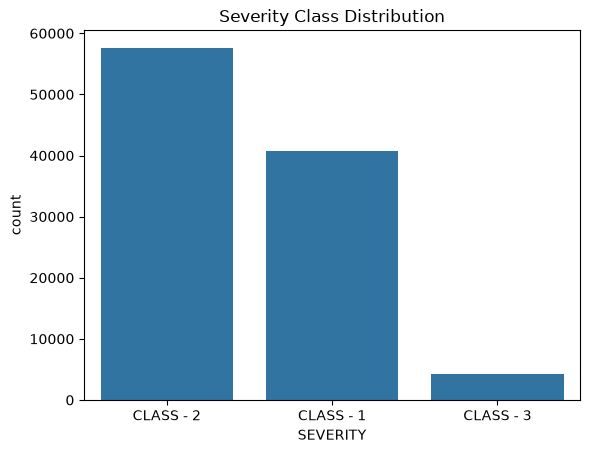

In [43]:
sns.countplot(
    data=df,
    x="SEVERITY"
)

plt.title("Severity Class Distribution")
plt.show()

In [44]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

DOB_VIOLATION_NUMBER          80813
BIN                              95
BLOCK                           487
LOT                             487
RESPONDENT_NAME                  75
RESPONDENT_HOUSE_NUMBER       22754
RESPONDENT_STREET              7784
RESPONDENT_CITY                8279
RESPONDENT_ZIP                 8932
VIOLATION_DESCRIPTION             8
SECTION_LAW_DESCRIPTION1       7994
INFRACTION_CODE2              99864
SECTION_LAW_DESCRIPTION2     100342
INFRACTION_CODE3             102447
SECTION_LAW_DESCRIPTION3     102447
INFRACTION_CODE4             102467
SECTION_LAW_DESCRIPTION4     102467
INFRACTION_CODE5             102467
SECTION_LAW_DESCRIPTION5     102467
INFRACTION_CODE6             102467
SECTION_LAW_DESCRIPTION6     102467
INFRACTION_CODE7             102467
SECTION_LAW_DESCRIPTION7     102467
INFRACTION_CODE8             102467
SECTION_LAW_DESCRIPTION8     102467
INFRACTION_CODE9             102467
SECTION_LAW_DESCRIPTION9     102467
INFRACTION_CODE10           

In [45]:
duplicate_count = df.duplicated().sum()

print(
    "Duplicate records:",
    duplicate_count
)

Duplicate records: 0


In [46]:
df[numerical_features].describe()

,BIN,BLOCK,LOT
count,1.023720e+05,101980.000000,101980.000000
mean,2.901839e+06,3900.134330,336.380977
std,1.206617e+06,3253.182799,1442.267420
min,1.000000e+06,1.000000,0.000000
25%,2.012957e+06,1475.000000,13.000000
50%,3.089176e+06,2999.000000,33.000000
75%,4.032027e+06,5399.000000,59.000000
max,5.871468e+06,20179.000000,9999.000000


In [47]:
df["PENALITY_IMPOSED"] = (
    df["PENALITY_IMPOSED"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["PENALITY_IMPOSED"] = pd.to_numeric(
    df["PENALITY_IMPOSED"],
    errors="coerce"
)

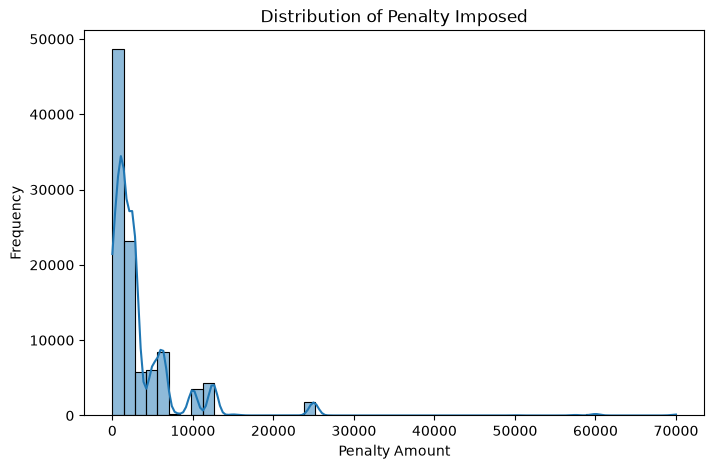

In [61]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["PENALITY_IMPOSED"],
    bins=50,
    kde=True
)

plt.title("Distribution of Penalty Imposed")
plt.xlabel("Penalty Amount")
plt.ylabel("Frequency")

plt.show()

In [48]:
financial_columns = [
    "AMOUNT_PAID",
    "BALANCE_DUE"
]


for col in financial_columns:
    
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )
    
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

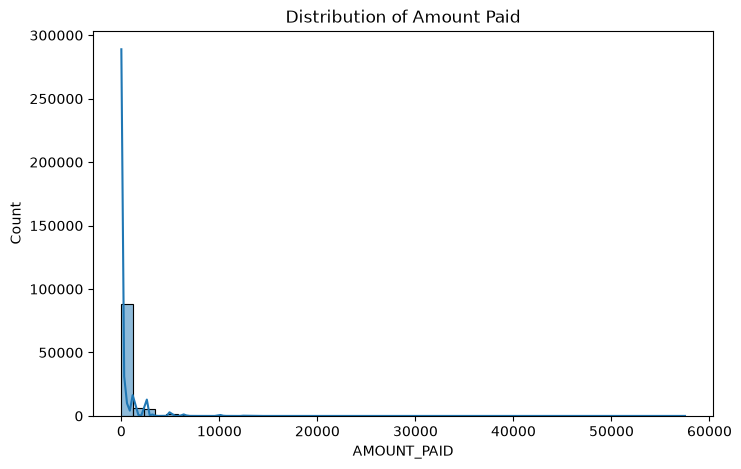

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["AMOUNT_PAID"],
    bins=50,
    kde=True
)

plt.title("Distribution of Amount Paid")

plt.show()

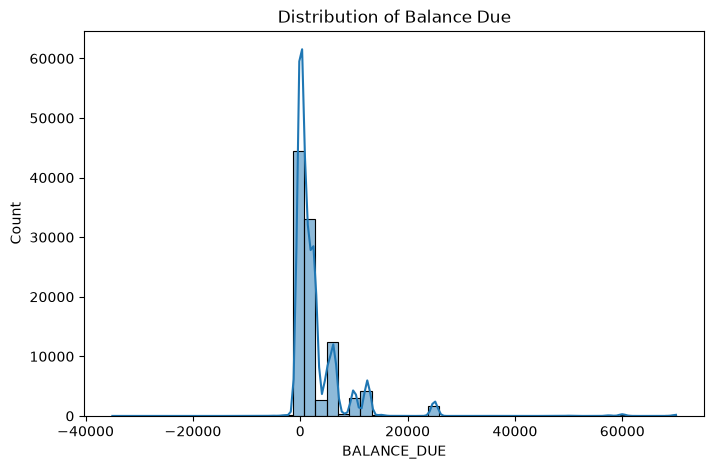

In [63]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["BALANCE_DUE"],
    bins=50,
    kde=True
)

plt.title("Distribution of Balance Due")

plt.show()

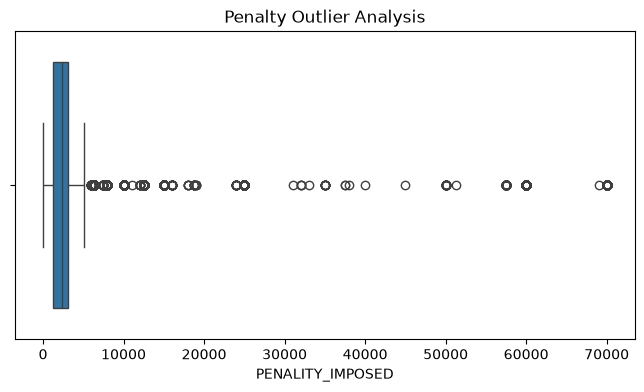

In [64]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["PENALITY_IMPOSED"]
)

plt.title("Penalty Outlier Analysis")

plt.show()

In [49]:
Q1 = df["PENALITY_IMPOSED"].quantile(0.25)

Q3 = df["PENALITY_IMPOSED"].quantile(0.75)

IQR = Q3 - Q1


lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


outliers = df[
    (df["PENALITY_IMPOSED"] < lower) |
    (df["PENALITY_IMPOSED"] > upper)
]


print("Number of outliers:", len(outliers))

Number of outliers: 18731


In [50]:
df["VIOLATION_TYPE"].value_counts().head(10)

VIOLATION_TYPE
Construction           74655
Unknown                13585
Elevators               6999
Boilers                 2275
Zoning                  1385
Local Law               1241
Quality of Life          917
Site Safety              580
Cranes and Derricks      355
Plumbing                 280
Name: count, dtype: int64

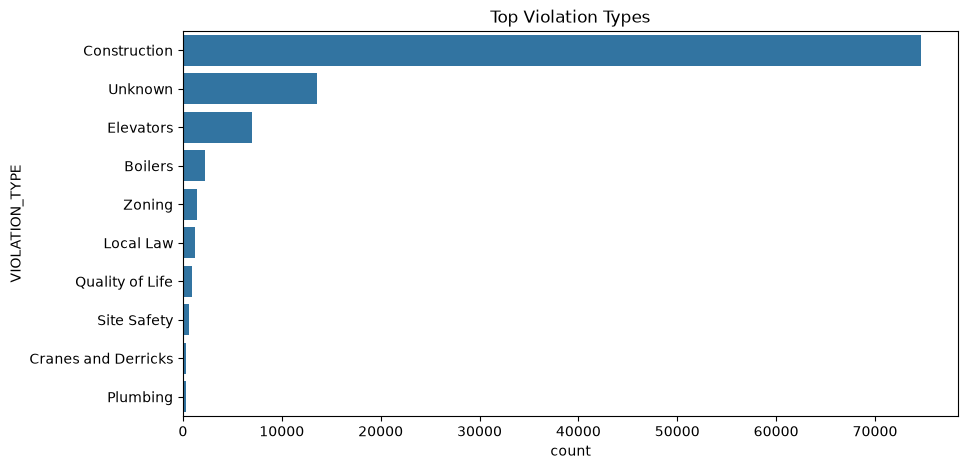

In [51]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="VIOLATION_TYPE",
    order=df["VIOLATION_TYPE"].value_counts().head(10).index
)

plt.title("Top Violation Types")

plt.show()

In [52]:
pd.crosstab(
    df["VIOLATION_TYPE"],
    df["SEVERITY"]
)

SEVERITY,CLASS - 1,CLASS - 2,CLASS - 3
VIOLATION_TYPE,,,
Boilers,100,1920,255
Construction,29573,42196,2886
Cranes and Derricks,114,241,0
Elevators,3668,3329,2
Local Law,0,1241,0
Plumbing,107,160,13
Public Assembly,17,0,0
Quality of Life,754,163,0
Signs,106,72,0


In [53]:
violation_severity_percentage = pd.crosstab(
    df["VIOLATION_TYPE"],
    df["SEVERITY"],
    normalize="index"
)

violation_severity_percentage

SEVERITY,CLASS - 1,CLASS - 2,CLASS - 3
VIOLATION_TYPE,,,
Boilers,0.043956,0.843956,0.112088
Construction,0.396129,0.565213,0.038658
Cranes and Derricks,0.321127,0.678873,0.000000
Elevators,0.524075,0.475639,0.000286
Local Law,0.000000,1.000000,0.000000
Plumbing,0.382143,0.571429,0.046429
Public Assembly,1.000000,0.000000,0.000000
Quality of Life,0.822246,0.177754,0.000000
Signs,0.595506,0.404494,0.000000


In [54]:
df["ISSUE_DATE"].head()

0    20260601
1    20250805
2    20260624
3    20251203
4    20260722
Name: ISSUE_DATE, dtype: int64

In [55]:
df["ISSUE_DATE"] = pd.to_datetime(
    df["ISSUE_DATE"].astype(str),
    format="%Y%m%d"
)

In [56]:
df["ISSUE_DATE"].head()

0   2026-06-01
1   2025-08-05
2   2026-06-24
3   2025-12-03
4   2026-07-22
Name: ISSUE_DATE, dtype: datetime64[us]

Date information can provide temporal patterns for prediction.

In [57]:
df["ISSUE_YEAR"] = df["ISSUE_DATE"].dt.year

df["ISSUE_MONTH"] = df["ISSUE_DATE"].dt.month

df["ISSUE_DAY"] = df["ISSUE_DATE"].dt.day

df["ISSUE_DAY_OF_WEEK"] = df["ISSUE_DATE"].dt.dayofweek

In [58]:
df[
[
    "ISSUE_DATE",
    "ISSUE_YEAR",
    "ISSUE_MONTH",
    "ISSUE_DAY",
    "ISSUE_DAY_OF_WEEK"
]
].head()

,ISSUE_DATE,ISSUE_YEAR,ISSUE_MONTH,ISSUE_DAY,ISSUE_DAY_OF_WEEK
0,2026-06-01,2026,6,1,0
1,2025-08-05,2025,8,5,1
2,2026-06-24,2026,6,24,2
3,2025-12-03,2025,12,3,2
4,2026-07-22,2026,7,22,2


In [59]:
year_counts = df["ISSUE_YEAR"].value_counts().sort_index()

year_counts

ISSUE_YEAR
2025    57822
2026    44645
Name: count, dtype: int64

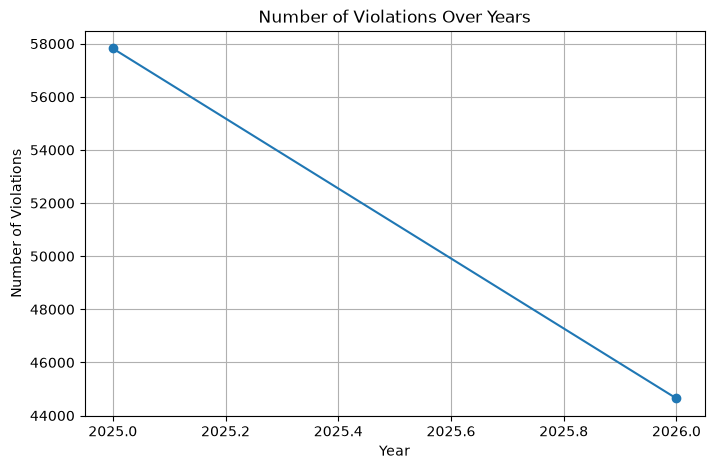

In [60]:
plt.figure(figsize=(8,5))

year_counts.plot(
    kind="line",
    marker="o"
)

plt.title("Number of Violations Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Violations")

plt.grid(True)

plt.show()

In [65]:
#Class imbalance
severity_counts = df["SEVERITY"].value_counts()

severity_counts

SEVERITY
CLASS - 2    57607
CLASS - 1    40673
CLASS - 3     4187
Name: count, dtype: int64

In [66]:
severity_percentage = (
    df["SEVERITY"]
    .value_counts(normalize=True)
    * 100
)

severity_percentage

SEVERITY
CLASS - 2    56.220051
CLASS - 1    39.693755
CLASS - 3     4.086194
Name: proportion, dtype: float64

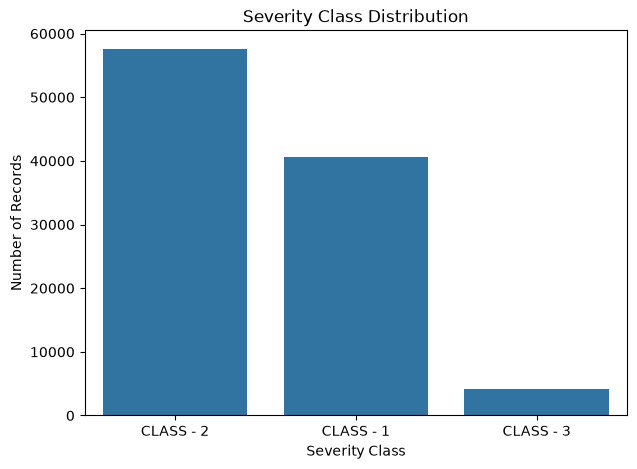

In [67]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="SEVERITY",
    order=df["SEVERITY"].value_counts().index
)

plt.title("Severity Class Distribution")
plt.xlabel("Severity Class")
plt.ylabel("Number of Records")

plt.show()

CLASS-2 has approximately 14 times more records than CLASS-3.Accuracy alone is not enough.

In [68]:
#Calculate imbalance ratio
class_ratio = (
    df["SEVERITY"]
    .value_counts()
    .max()
    /
    df["SEVERITY"]
    .value_counts()
    .min()
)

class_ratio

np.float64(13.758538332935276)

The BORO attribute was originally represented using numeric codes from 1 to 5. These codes correspond to the five New York City boroughs: Manhattan, Bronx, Brooklyn, Queens, and Staten Island.
Location information may contribute to severity prediction.

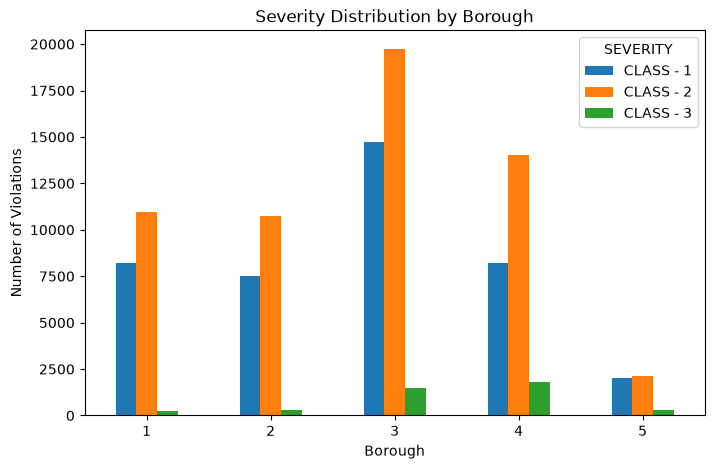

In [71]:
#visualization
boro_severity = pd.crosstab(
    df["BORO"],
    df["SEVERITY"]
)


boro_severity.plot(
    kind="bar",
    figsize=(8,5)
)


plt.title("Severity Distribution by Borough")

plt.xlabel("Borough")

plt.ylabel("Number of Violations")

plt.xticks(rotation=0)

plt.show()

<Figure size 1200x600 with 0 Axes>

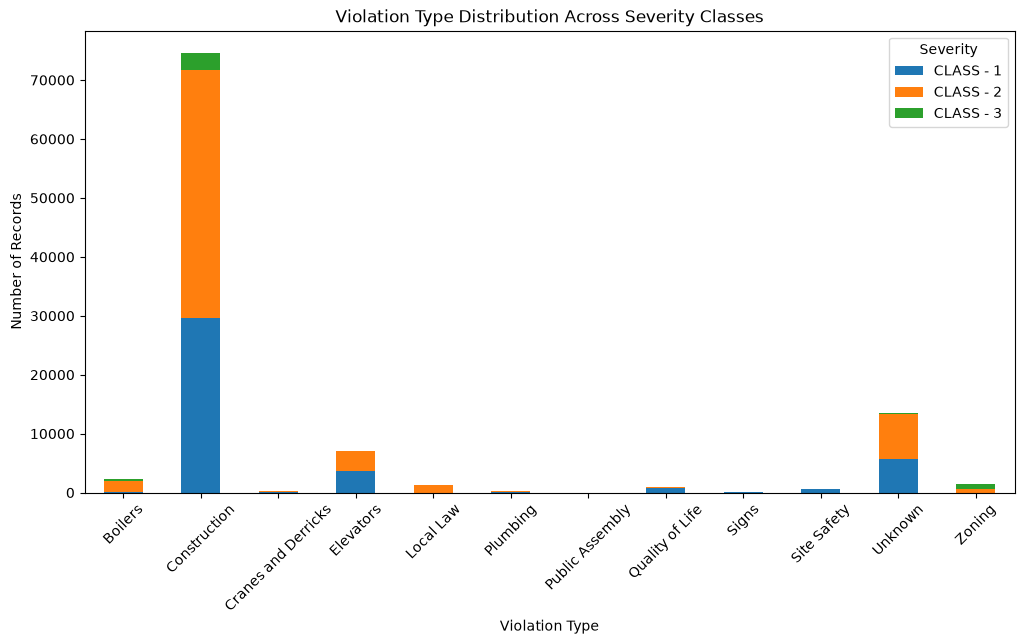

In [72]:
violation_severity = pd.crosstab(
    df["VIOLATION_TYPE"],
    df["SEVERITY"]
)


plt.figure(figsize=(12,6))

violation_severity.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Violation Type Distribution Across Severity Classes")

plt.xlabel("Violation Type")

plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.legend(title="Severity")

plt.show()

These variables may strongly predict severity.
They may be created after enforcement decisions.
Data Leakage Finding

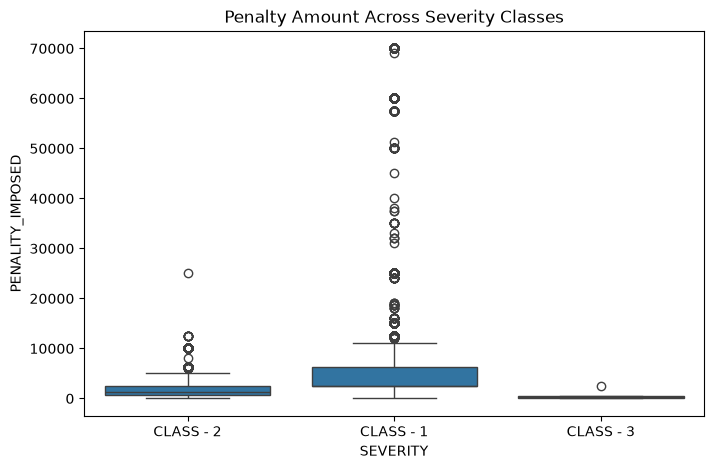

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="SEVERITY",
    y="PENALITY_IMPOSED"
)

plt.title("Penalty Amount Across Severity Classes")

plt.show()

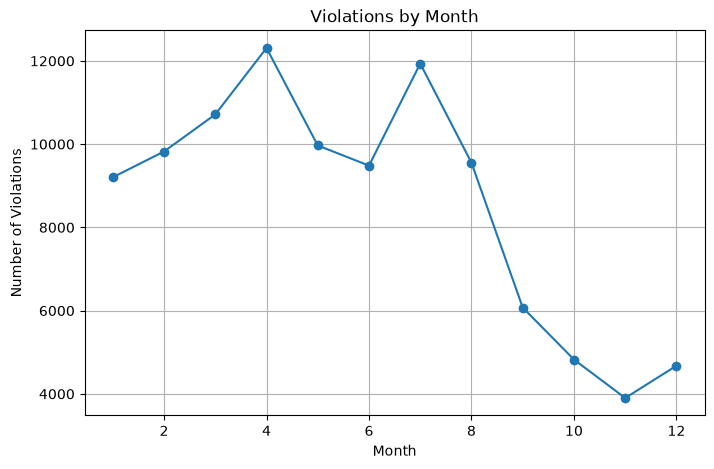

In [74]:
monthly_violations = (
    df["ISSUE_MONTH"]
    .value_counts()
    .sort_index()
)


plt.figure(figsize=(8,5))

monthly_violations.plot(
    kind="line",
    marker="o"
)

plt.title("Violations by Month")

plt.xlabel("Month")

plt.ylabel("Number of Violations")

plt.grid(True)

plt.show()

calculates the correlation coefficient between every pair of numerical columns.

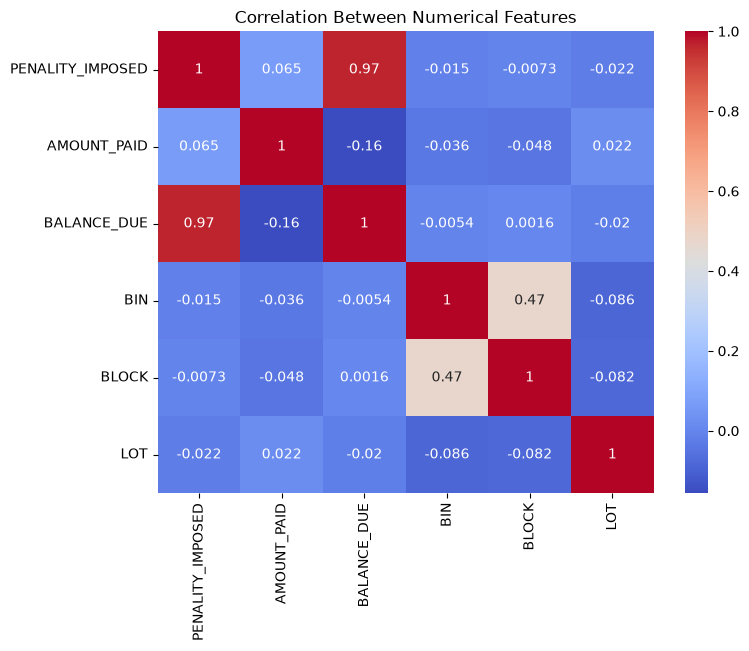

In [75]:
#correlation heatmap
numeric_cols = [
    "PENALITY_IMPOSED",
    "AMOUNT_PAID",
    "BALANCE_DUE",
    "BIN",
    "BLOCK",
    "LOT"
]


plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Features")

plt.show()

In [76]:
#Relationships
violation_severity = pd.crosstab(
    df["VIOLATION_TYPE"],
    df["SEVERITY"]
)

violation_severity

SEVERITY,CLASS - 1,CLASS - 2,CLASS - 3
VIOLATION_TYPE,,,
Boilers,100,1920,255
Construction,29573,42196,2886
Cranes and Derricks,114,241,0
Elevators,3668,3329,2
Local Law,0,1241,0
Plumbing,107,160,13
Public Assembly,17,0,0
Quality of Life,754,163,0
Signs,106,72,0


In [77]:
boro_severity = pd.crosstab(
    df["BORO"],
    df["SEVERITY"]
)

boro_severity

SEVERITY,CLASS - 1,CLASS - 2,CLASS - 3
BORO,,,
1,8200,10960,241
2,7525,10733,314
3,14737,19744,1492
4,8193,14029,1820
5,2018,2141,320


In [78]:
year_severity = pd.crosstab(
    df["ISSUE_YEAR"],
    df["SEVERITY"]
)

year_severity

SEVERITY,CLASS - 1,CLASS - 2,CLASS - 3
ISSUE_YEAR,,,
2025,22862,32399,2561
2026,17811,25208,1626


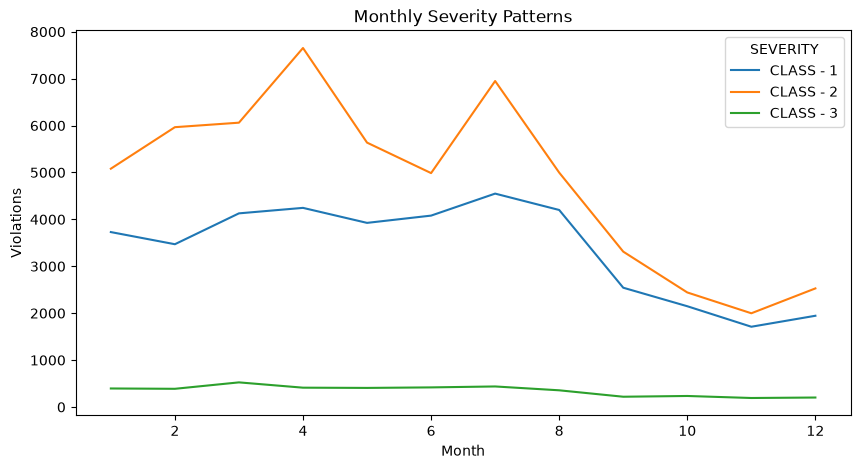

In [79]:
month_severity = pd.crosstab(
    df["ISSUE_MONTH"],
    df["SEVERITY"]
)

month_severity.plot(
    figsize=(10,5)
)

plt.title(
    "Monthly Severity Patterns"
)

plt.xlabel("Month")

plt.ylabel("Violations")

plt.show()

In [81]:
#Data Leakage Investigation
df.groupby("SEVERITY")[
[
"PENALITY_IMPOSED",
"AMOUNT_PAID",
"BALANCE_DUE"
]
].mean()

,PENALITY_IMPOSED,AMOUNT_PAID,BALANCE_DUE
SEVERITY,,,
CLASS - 1,5817.252748,564.829248,5196.197920
CLASS - 2,2085.626573,295.983058,1522.186123
CLASS - 3,295.013136,82.807022,209.595176


In [82]:
import re

severity_pattern = r"\b(class\s*-\s*1|class\s*-\s*2|class\s*-\s*3)\b"


severity_mentions = (
    df["VIOLATION_DESCRIPTION"]
    .fillna("")
    .str.contains(
        severity_pattern,
        case=False,
        regex=True
    )
)


severity_mentions.sum()

np.int64(1)

In [83]:
df.loc[
    severity_mentions,
    [
        "VIOLATION_DESCRIPTION",
        "SEVERITY"
    ]
]

,VIOLATION_DESCRIPTION,SEVERITY
44057,OBSERVED PREVIOUS CLASS-1 CONDITIONS STILL PRE...,CLASS - 1
